# Tutorial

**Notation.**
*Array* always refers to a NumPy array.

## Compliance minimization

Here we minimize the compliance in a linear elasticity problem.

The problem reads
$$
\min_{\Omega} \int_{\mathcal{D}} A_{\Omega}\sigma(u):e(u)
\quad\text{subject to}\quad
\int_{\mathcal{D}} \chi_{\Omega} = V
$$
where $u$ is the solution to
$$
\begin{array}{rlcc}
    -\mathrm{div} A_{\Omega} e(u) & = 0 & \text{in} & \mathcal{D}\\
                                u & = 0 & \text{on} & \Gamma_{d}\\
                 A_{\Omega} e(u)n & = g & \text{on} & \Gamma_{n}
\end{array}
$$

and $A_{\Omega} = \chi_{\Omega} + {10}^{-4}\chi_{\mathcal{D}\backslash\Omega}$.

### Symmetric cantilever

To address this problem, the class `Compliance(Model)` is constructed with the following methods:

* The method `pde(self, phi)` models the weak formulation of linear elasticity equations: Find $u \in  H^1_{\Gamma_0}(\mathcal{D}, \mathbb{R}^d)$ such that
    
    $$
        \int_{\mathcal{D}} A_{\Omega}\sigma(u):e(v) - \int_{\partial \mathcal{D}} g \cdot v = 0
        \qquad
        \forall \, v \in  H^1_{\Gamma_0}(\mathcal{D}, \mathbb{R}^d)
    $$

    To model $A_{\Omega}$, it is defined the attribute
    
    ```python
    self.A = lambda v: conditional(lt(v, 0.0), 1.0, 1e-3)
    ```
    
    in the constructor of the class (see the method `__init__`). Then we write `self.A(phi)`.

* The method `adjoint(self, phi, U)` is empty because this is a self-adjoint problem.

* The method `cost(self, phi, U)` returns the cost function
    $$
        J(\Omega) = \int_{\mathcal{D}} A_{\Omega}\sigma(u):e(u)
    $$
    The argument `U` represents a list of state functions. Since in this case there is only one state, we use `U[0]` (element at position zero) as $u$.	

* The method `constraint(self, phi, U)` models the volume constraint function
    
    $$
        C(\Omega) = \frac{1}{V} \int_{\mathcal{D}} \chi_{\Omega}
    $$
    
    The attribute
    
    ```python
    self.chi = lambda w: conditional(lt(w, 0.0), 1.0, 0.0)
    ```
    is used to model $\chi_{\Omega}$. We write `self.chi(phi)`. The volume $V$ is also a attribute of the class, `self.vol`.

* The method `derivative(self, phi, U, P)` returns the components $S_0$ and $S_1$ of the distributed shape derivatives. For the cost function $J$, the components $S_0$ and $S_1$ are given by
    $$
        \begin{aligned}
            S_0 &= \boldsymbol{0} \\
            S_1 &= A_{\Omega} (2{Du}^{\top}\sigma(u)- \sigma(u):e(u))I
        \end{aligned}
    $$
    where $u$ is the solution to the weak formulation of the problem, which is represented by `U[0]`. For the constraint function we have
    $$
        \begin{aligned}
            S_0 &= \boldsymbol{0} \\
            S_1 &= \frac{1}{V} \chi_{\Omega} I
        \end{aligned}
    $$
    The method must return two lists containing the $S_0$ and $S_1$ components respectively. 


* The method `bilinear_form(self, th, xi)` contains the bilinear form to be used to calculate the vector field $\theta$. In this case,
    $$
        B(\theta, \xi) =  {10}^{-1} \int_{\mathcal{D}} \theta \cdot \xi + 
            \int_{\mathcal{D}} D\theta : D\xi +
            {10}^4 \int_{\partial \mathcal{D}}  (\theta \cdot n) (\xi \cdot n)
    $$
    with $\theta, \xi \in H^1(\mathcal{D}, \mathbb{R}^d)$.

With the model class defined, the next step is to build the domain. Consider the rectangular domain $\Omega = (0, 2)\times(0, 1)$. We will apply one force on the subset of boundary determined by the line segment that is bounded by the points $(2, 0.45)$ and $(2, 0.55)$. The Dirichlet condition will be applied on the line segment that is bounded by the points $(0, 0)$ and $(0, 1)$. We use the function `create_domain_2d_DP` to create the domain. We define the following arguments:

```python
vertices = np.array([
    (0.0, 0.0),
    (2.0, 0.0),
    (2.0, 0.45),
    (2.0, 0.55),
    (2.0, 1.0),
    (0.0, 1.0)
])
    
dir_idx, dir_mkr = [6], 1
neu_idx, neu_mkr = [3], 2
boundary_parts = [
    (dir_idx, dir_mkr, "dir"),
    (neu_idx, neu_mkr, "neu")
]
```

The array `vertices` contains the vertices of the boundary domain, considering the line segments where we want to apply the Dirichlet and Neumann conditions. By convention, the vertices are written in counter clockwise direction. The list `boundary_parts` contains the segment numbers, marks, and names corresponding to the line segments where we will apply the Dirichlet and Neumann conditions. For instance, the list `dir_idx` contains the number `6`, because we want to apply the Dirichlet condition only on the sixth line segment (which have initial point `(0.0, 1.0)` and final point `(0.0, 0.0)`). The marks `dir_mkr` and `neu_mkr` are integers grater than `0` to identify the groups of segments.

Thus, we have the following correspondence:

* $\Gamma_d$ is represented by `(dir_idx, dir_mkr, "dir")`
* $\Gamma_n$ is represented by `(neu_idx, neu_mkr, "neu")`

Once the domain is in place, we can proceed to create a model for our test, that is, to instantiate an object of the class `Compliance`. The more important arguments are the following:
```python
# Space for the PDE solution
space = dib.create_space(domain, "CG", rank_dim)
# Dirichlet condition
dirichlet_bcs = dib.homogeneous_dirichlet(
    domain, space, boundary_tags,
    [dir_mkr], rank_dim
)
# Boundary to force application 
ds_g = dib.marked_ds(
    domain,
    boundary_tags,
    [neu_mkr]
)
```

The function `create_space` is just a wrapper of the function `functionspace` of `dolfinx.fem`.
It creates the finite element space for the weak solution.
The function `homogeneous_dirichlet` returns a list with the boundary condition marked with `dir_mkr`.
Note that it is necessary to pass as an argument the boundary tags of the domain.
Finally, the function `marked_ds` returns the `ds`-measure corresponding to the Neumann condition,
which will be used to build the weak form of the problem. Now we create the model and set a constraint for the vector field:
```python
# Create the model
md = Compliance(
    dim, domain, space,
    g, ds_g[0],
    dirichlet_bcs, area
)

@dib.region_of(domain)
def sub_domain(x):
    # 0.42 < x[1] < 0.58
    # 1.95 < x[0]
    ineqs = (
        x[1] - 0.42,
        0.58 - x[1],
        x[0] - 1.95
    )
    return ineqs

md.sub = [sub_domain.expression()]
```

The function `sub_domain` determines the set
$$
\Omega_0 = \left\{ (x,y)\in \mathcal{D} \mid 1.95 < x,\, 0.42 < y < 0.58   \right\}.
$$
We decorate `sub_domain` with `@region_of(domain)`,
which allows to call the method `expression()`.
This method transform the function `sub_domain` to an UFL expression.
With this, the model will add a term of the form
$$
{10}^4 \int_{\mathcal{D}} (\theta \cdot \xi) \chi_{\Omega_0}
$$
to the bilinear form of the velocity equation. Thus, we can impose (almost) zero velocity on $\Omega_0$.

A initial level set function must be provided in the form of `(centers, radii)`, where `centers` is an array of points in $\mathcal{D}$ and `radii` is an array de positive numbers. The initial level set will be positive on the ball of center `centers[i]` and radius `radii[i]` for each `i`, and negative otherwise.

Finally, call the function `runDP` with the following arguments:
```python
dib.runDP(
    model = md,
    initial_guess = (centers, radii),
    niter = 100,
    save_path = test_path,
    reinit_step = 4,
    ctrn_tol = 1e-3,
    dfactor = 1e-1,
    smooth = True
)
```

**DP** refers to the parallelization mode: Data Parallelism.
This test is written in the function `test_01` of the file `test.py`.
In the terminal, run
```
mpirun -np 2 python test.py 01
```
to execute with 2 processes. Bellow the numerical results:

In [11]:
!mpirun -np 2 python test.py 01 > ../results/t01/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


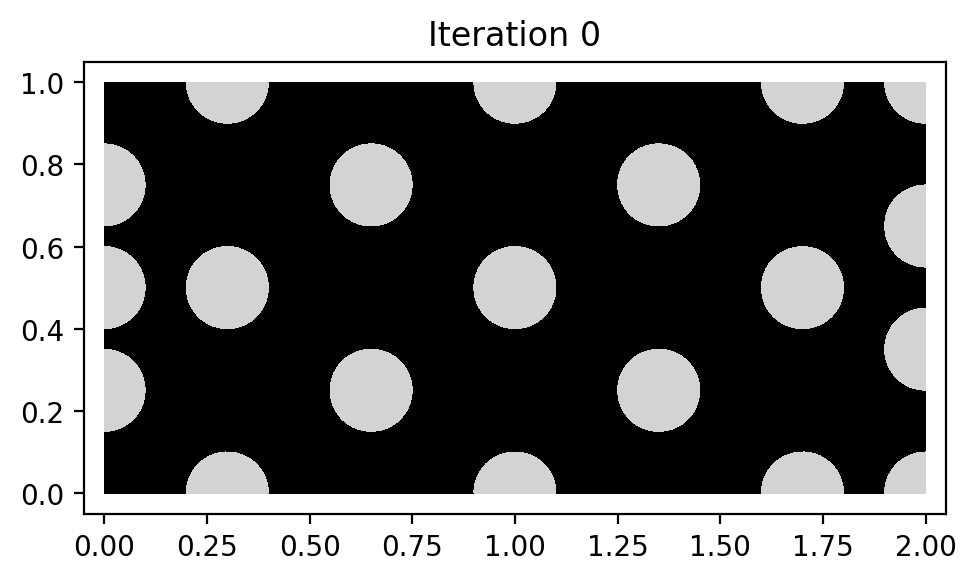

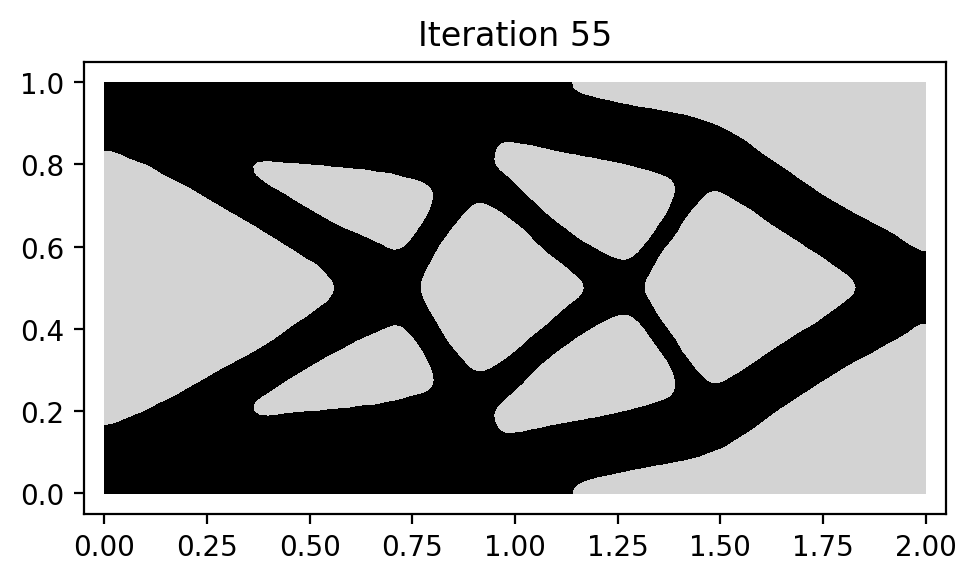

In [1]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial
plot_tutorial(h5file = "../results/t01/results.h5", size = (6, 3))

### Cantilever with two loads

In order to consider multiple forces, we write the class `CompliancePlus(Model)` with the following methods:

* The method `pde(self, phi)` models the weak formulation of linear elasticity equations for each force $g_i$: Find $u \in  H^1_{\Gamma_0}(\mathcal{D}, \mathbb{R}^d)$ such that
    $$
        \int_{\mathcal{D}} A_{\Omega}\sigma(u):e(v) - \int_{\partial \mathcal{D}} g_i \cdot v = 0
        \qquad
        \forall \, v \in  H^1_{\Gamma_0}(\mathcal{D}, \mathbb{R}^d)
    $$
    for $i = 1, 2$.

* The method `adjoint(self, phi, U)` is empty because this is a self-adjoint problem.

* The method `cost(self, phi, U)` returns the cost functional
    $$
        J(\Omega) = \sum_{i=1}^{2} \int_{\mathcal{D}} A_{\Omega}\sigma(u_i):e(u_i)
    $$

* The method `constraint(self, phi, U)` models the volume constraint function
    $$
        C(\Omega) = \frac{1}{V} \int_{\mathcal{D}} \chi_{\Omega}
    $$

* The method `derivative(self, phi, U, P)` returns the distributed shape derivatives corresponding to the cost and constraint functions:
    $$
        \begin{aligned}
            S_0 &= \vec{0} \\
            S_1 &= \sum_{i=1}^{2} A_{\Omega} (2{Du_i}^{\top}\sigma(u_i)- \sigma(u_i):e(u_i))I
        \end{aligned}
    $$
    $$
        \begin{aligned}
            S_0 &= \vec{0} \\
            S_1 &= \frac{1}{V} \chi_{\Omega} I
        \end{aligned}
    $$

* The method `bilinear_form(self, th, xi)` is the same as the previous example.

In [5]:
!mpirun -np 2 python test.py 04 > ../results/t04/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


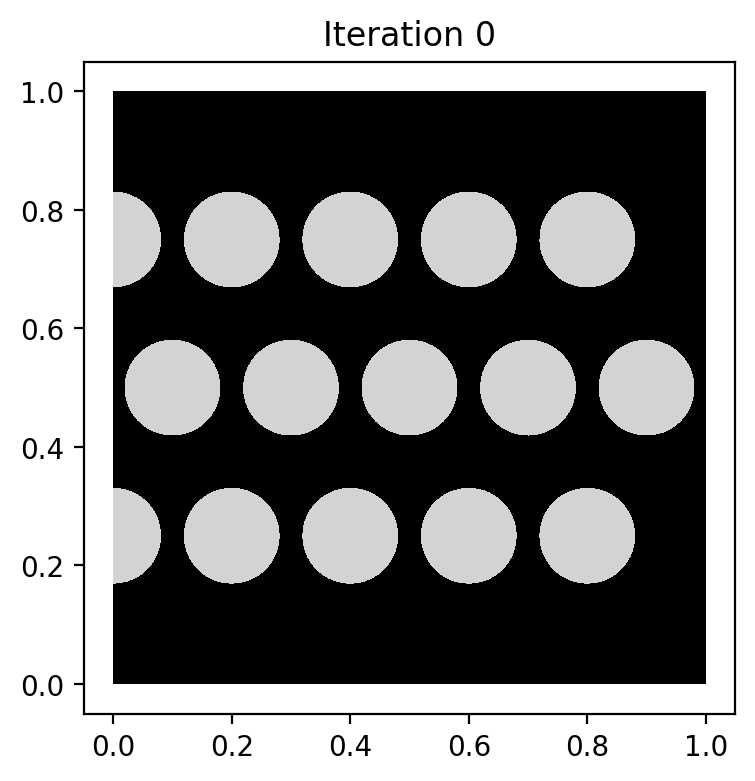

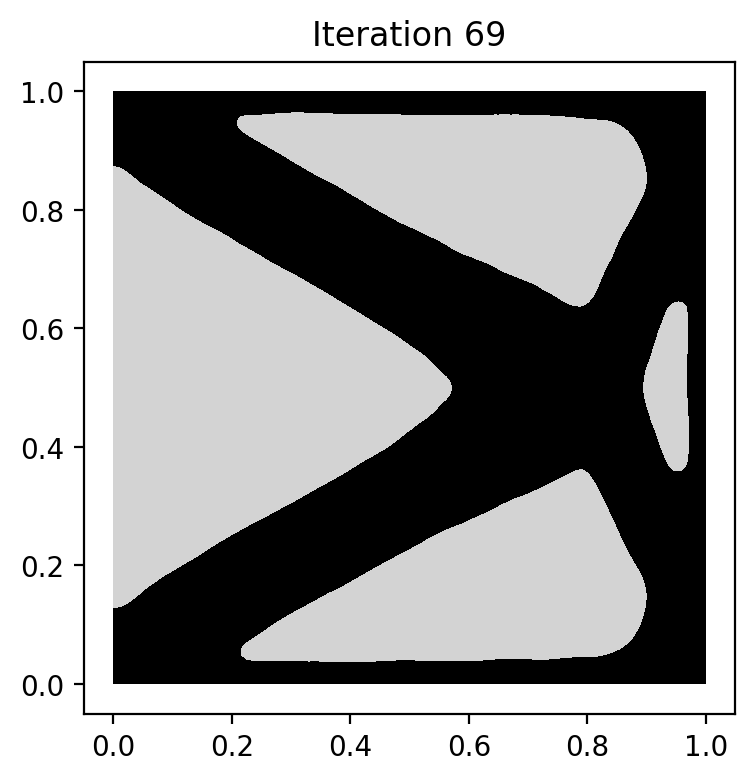

In [4]:
%config InlineBackend.figure_format = 'retina'
from plots import plot_tutorial

plot_tutorial("../results/t04/results.h5", (4, 4))

## Elasticity inverse problem

## Heat conduction problem

The problem reads
$$
\min_{\Omega} \int_{\mathcal{D}} A_{\Omega}\left|\nabla u\right|^{2}
\quad\text{subject to}\quad
\int_{\mathcal{D}} \chi_{\Omega} = V
$$
where $u$ is the solution to
$$
\begin{array}{rlcc}
    -\mathrm{div}(A_{\Omega} \nabla u) & = f & \text{in} & \mathcal{D}\\
                                     u & = 0 & \text{on} & \Gamma_{d}\\
                        \partial_{n} u & = 0 & \text{on} & \Gamma_{n}
\end{array}
$$

and $A_{\Omega} = \chi_{\Omega} + {10}^{-3}\chi_{\mathcal{D}\backslash\Omega}$.